In [9]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os

In [10]:
train_dir = "../../datasets/FruitinAmazon/train/"
test_dir = "../../datasets/FruitinAmazon/test/"
img_height, img_width = 128, 128
batch_size = 32
validation_split = 0.2
seed = 123
epochs = 10

TASK 1: Data Inspection
No corrupted images found.


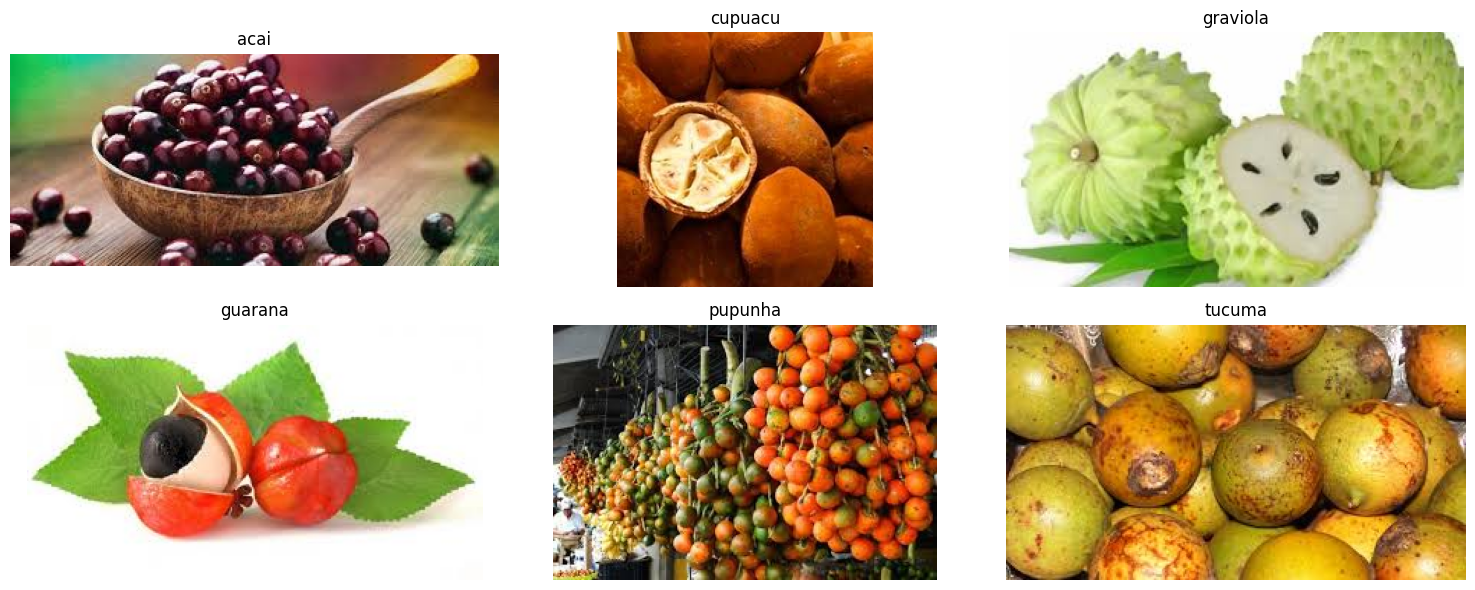

Observed 6 classes. Each folder contains images of that fruit.


In [11]:
import random

def check_corrupted_images(directory):
    """Check and remove corrupted images in the directory tree."""
    corrupted_count = 0
    for root, dirs, files in os.walk(directory):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff')):
                file_path = os.path.join(root, file)
                try:
                    with Image.open(file_path) as img:
                        img.verify()
                except (IOError, SyntaxError, OSError):
                    print(f"Removed corrupted image: {file_path}")
                    os.remove(file_path)
                    corrupted_count += 1
    if corrupted_count == 0:
        print("No corrupted images found.")
    else:
        print(f"Removed {corrupted_count} corrupted images.")

def visualize_one_per_class(train_dir):
    """Display one image from each class in a grid."""
    classes = [d for d in os.listdir(train_dir) 
               if os.path.isdir(os.path.join(train_dir, d))]
    classes.sort()
    num_classes = len(classes)
    
    fig, axes = plt.subplots(2, (num_classes + 1) // 2, figsize=(15, 6))
    axes = axes.flatten()
    
    for i, class_name in enumerate(classes):
        class_path = os.path.join(train_dir, class_name)
        images = [f for f in os.listdir(class_path) 
                  if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        if images:
            img_path = os.path.join(class_path, random.choice(images))
            img = Image.open(img_path)
            axes[i].imshow(img)
            axes[i].set_title(class_name)
            axes[i].axis('off')
    
    # Hide unused subplots
    for j in range(num_classes, len(axes)):
        axes[j].axis('off')
    
    plt.tight_layout()
    plt.show()
    print(f"Observed {num_classes} classes. Each folder contains images of that fruit.")

# Run Task 1
print("=" * 50)
print("TASK 1: Data Inspection")
print("=" * 50)
check_corrupted_images(train_dir)
visualize_one_per_class(train_dir)

In [ ]:
# Infer number of classes from training directory
class_names = sorted(
    [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]
)
num_classes = len(class_names)

model = keras.Sequential([
    # Convolutional Block 1
    layers.Conv2D(32, (3,3), padding='same', strides=1, activation='relu', input_shape=(img_height, img_width, 3)),
    layers.MaxPooling2D(pool_size=(2,2), strides=2),
    
    # Convolutional Block 2
    layers.Conv2D(32, (3,3), padding='same', strides=1, activation='relu'),
    layers.MaxPooling2D(pool_size=(2,2), strides=2),
    
    # Flatten and Fully Connected Layers
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

# Display model summary
model.summary()

NameError: name 'num_classes' is not defined